# CHM
Run inference on an image with the CHM. Could be used to link remote + field tree locations.

In [1]:
import pickle
import os
import urllib
import torch

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torchvision.transforms.functional as TF
from sklearn.decomposition import PCA
from scipy import signal

import sys
import os
from pathlib import Path
%load_ext autoreload
%autoreload 2
sys.path.insert(0, str(Path("../dinov3/").resolve())) #import modules specifically from dinov3/

In [2]:
from dinov3.hub.backbones import dinov3_vit7b16, dinov3_vitl16
from dinov3.models.depth_model import Dinov3DepthDPT

model = Dinov3DepthDPT()

In [4]:
url = "../dinov3/dinov3/weights/dinov3-sat-vitl-3dep-256bin-8maxdepth-loglin.pt" 
state_dict = torch.load(url, map_location="cpu")
state_dict = state_dict['model_state_dict']
for k in list(state_dict.keys()):
    if 'module.' in k:
        new_k = k.replace('module.','')
        state_dict[new_k] = state_dict.pop(k)
model.load_state_dict(state_dict, strict=False)

<All keys matched successfully>

In [5]:
from PIL import Image
import urllib

# preprocess image
PATCH_SIZE = 16
IMAGE_SIZE = 416

def resize_transform(
    mask_image: Image,
    image_size: int = IMAGE_SIZE,
    patch_size: int = PATCH_SIZE,
) -> torch.Tensor:
    '''
    image is resized to (h_patches * patch_size, w_patches * patch_size) 
    so both height and width are exact multiples of the patch size
    '''
    w, h = mask_image.size
    h_patches = int(image_size / patch_size)
    w_patches = int((w * image_size) / (h * patch_size))
    return TF.to_tensor(TF.resize(mask_image, (h_patches * patch_size, w_patches * patch_size)))

# scale input
image = Image.open("test.png")
MEAN = (0.430, 0.411, 0.296 )
STD = (0.213, 0.156, 0.143 )

image_resized = resize_transform(image)
image_resized_norm = TF.normalize(image_resized, mean=MEAN, std=STD)

In [6]:
# inference
with torch.inference_mode():
    with torch.no_grad():
        pred = model(image_resized_norm.unsqueeze(0))

/Users/jessica.ertel/miniforge3/envs/dino3/lib/python3.11/site-packages/torch/amp/autocast_mode.py:250: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


<Axes: >

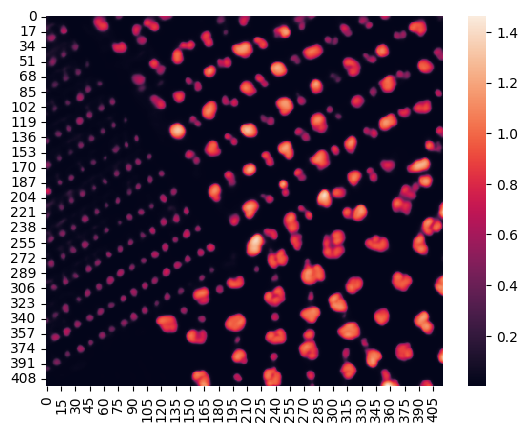

In [8]:
# visualize
import seaborn as sns
sns.heatmap(pred.squeeze().cpu())

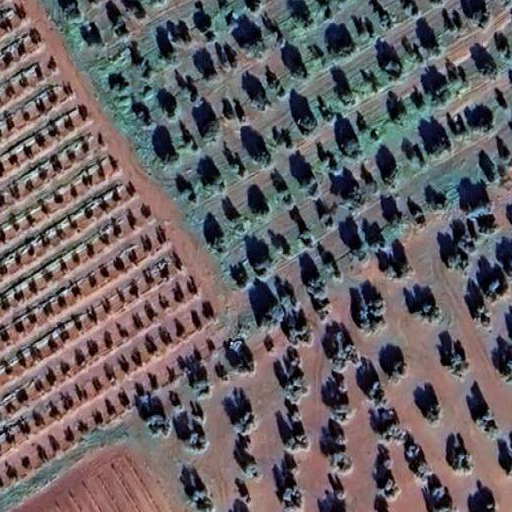

In [9]:
image